In [ ]:
from astropy import units as u
from astropy.constants import G, c
from matplotlib import pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import spacehub_calc
from spacehub_calc import TwoBodyOrbit, mag
import matplotlib.animation as animation
from IPython.display import HTML
from orbits import distance, get_com, calc_angle


In [2]:
m = 1 * u.Msun
a_b = 15 * u.AU
mu = m**2/(m+m)
v_inf = np.sqrt(1.5 * G * (m**2) / (a_b * mu))
v_inf.to(u.km/u.s)

<Quantity 13.32011912 km / s>

In [3]:
#Define input files
sample_file = "simulation_results/2+1_sample-2d.txt"
ptc_file = "simulation_results/2+1_ptcres-2d.txt"
inner_orb_res = "simulation_results/2+1_inner_orbres-2d.txt"
incident_orb_res = "simulation_results/2+1_incident_orbres-2d.txt"

In [4]:
output_dataframe = pd.DataFrame(columns=["b", "azi", "incl", "id", "px", "py", "pz", "vxc", "vyc", "vzc"])
with open(ptc_file, 'r') as file:
    b, azi, incl = 0, 0, 0
    for line in file:
        if len(line.split(",")) == 3:
            b = float(line.strip().split(",")[0])
            azi = float(line.strip().split(",")[1])
            incl = float(line.strip().split(",")[2])
        elif len(line.split(",")) == 9:
            l = line.strip().split(",")
            if l[0] == "time":
                continue
            #time = l[0]
            id = int(l[1])
            #m = l[2]
            px = float(l[3])
            py = float(l[4])
            pz = float(l[5])
            vx = float(l[6])
            vy = float(l[7])
            vz = float(l[8])
            row = {"b":b, "azi":azi, "incl":incl, "id":id, "px":px, "py":py, "pz":pz, "vx":vx, "vy":vy, "vz":vz}
            output_dataframe = pd.concat([output_dataframe, pd.DataFrame(row, index=[len(output_dataframe)])])

#output_dataframe

In [5]:
output_dataframe

,b,azi,incl,id,px,py,pz,vxc,vyc,vzc,vx,vy,vz
0,0.1,0.000000,0.0,0,-94.6983,-0.508766,0.0,NaN,NaN,NaN,-0.138037,0.072177,0.0
1,0.1,0.000000,0.0,1,230.0390,-56.954100,0.0,NaN,NaN,NaN,0.258891,-0.059620,0.0
2,0.1,0.000000,0.0,2,-135.3410,57.462900,0.0,NaN,NaN,NaN,-0.120853,-0.012558,0.0
3,0.1,0.128228,0.0,0,-124.2100,38.006100,0.0,NaN,NaN,NaN,-0.179005,0.118959,0.0
4,0.1,0.128228,0.0,1,259.5680,-96.805400,0.0,NaN,NaN,NaN,0.302602,-0.106151,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,30.0,6.154960,0.0,1,-38.0451,155.271000,0.0,NaN,NaN,NaN,0.095455,0.313525,0.0
7496,30.0,6.154960,0.0,2,85.7899,-314.416000,0.0,NaN,NaN,NaN,0.110352,-0.328495,0.0
7497,30.0,6.283190,0.0,0,-36.6721,152.450000,0.0,NaN,NaN,NaN,-0.111211,0.443954,0.0
7498,30.0,6.283190,0.0,1,-44.3668,151.498000,0.0,NaN,NaN,NaN,0.006000,-0.127889,0.0


Todo:
- If distance between a,b is less than distance between c and a/b, count as ionized 
- add as column to the id=0 row
- mask dataframe by id=0
- plot results

In [12]:
#Yes I know it does not make complete sense to work in the reference frame of particle 0, but I do not care because I already had this code written
system_dists = pd.DataFrame(columns=["b", "azi", "incl", "d01", "d02", "d12", "binary_components"])
resdf = pd.DataFrame(columns=["b", "azi", "incl", "id", "Rx", "Ry", "Rz", "Vx", "Vy", "Vz"])
num_particles = output_dataframe["id"].nunique()
for index, row in output_dataframe.iterrows():
    if row["id"] != 0:
        continue
    
    x0, y0, z0 = row["px"], row["py"], row["pz"]
    vx0, vy0, vz0 = row["vxc"], row["vyc"], row["vzc"]
    row_0 = {"b":row["b"], "azi":row["azi"], "incl": row["incl"], "id":row["id"], "Rx":0, "Ry":0, "Rz":0, "Vx":0, "Vy":0, "Vz":0, "R0n":0}
    resdf = pd.concat([resdf, pd.DataFrame(row_0, index=[index])])
    for n in range(1, num_particles):
        pid = output_dataframe["id"][index+n]
        dx = x0 - output_dataframe["px"][index+n]
        dy = y0 - output_dataframe["py"][index+n]
        dz = z0 - output_dataframe["pz"][index+n]
        vx = vx0 - output_dataframe["vxc"][index+n]
        vy = vy0 - output_dataframe["vyc"][index+n]
        vz = vz0 - output_dataframe["vzc"][index+n]
        row_p = {"b":row["b"], "azi":row["azi"], "incl": row["incl"], "id":pid, "Rx":dx, "Ry":dy, "Rz":dz, "Vx":vx, "Vy":vy, "Vz":vz, "R0n":mag([dx, dy, dz])}
        resdf = pd.concat([resdf, pd.DataFrame(row_p, index=[index+n])])

    d01 = resdf["R0n"][index+1]
    d02 = resdf["R0n"][index+2]
    d12x = (resdf["Rx"][index+1] - resdf["Rx"][index+2])
    d12y = (resdf["Ry"][index+1] - resdf["Ry"][index+2])
    d12z = (resdf["Rz"][index+1] - resdf["Rz"][index+2])
    d12 = mag([d12x, d12y, d12z])
    print(d01, d02, d12)
    print(min(d01, d02, d12))
    if min(d01, d02, d12) == d01:
        ib_comp = (0,1)
    if min(d01, d02, d12) == d01:
        ib_comp = (0,2)
    if min(d01, d02, d12) == d12:
        ib_comp = (1,2)
    dists = {"b":row["b"], "azi":row["azi"], "incl":row["incl"], "d01":d01, "d02":d02, "d12":d12, "binary_components":ib_comp}
    system_dists = pd.concat([system_dists, pd.DataFrame(dists, index=[len(system_dists)])])
    #0-1, 0-2, 1-2

resdf

329.60641641458005 70.79931583077308 382.8756903865796
70.79931583077308
no min


NameError: name 'ib_comp' is not defined

In [ ]:
system_dists

<Axes: xlabel='Rx', ylabel='Ry'>

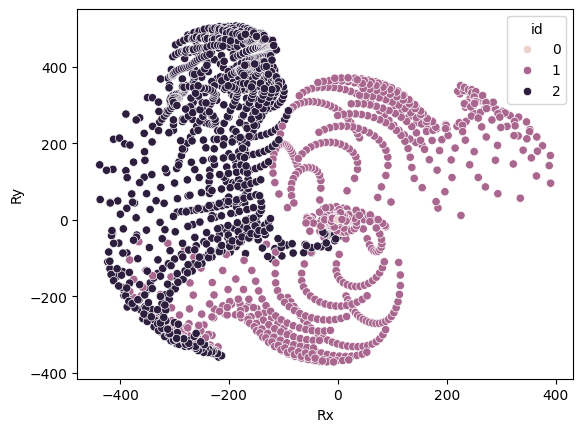

In [ ]:

sns.scatterplot(data=resdf[resdf["b"]>15], x="Rx", y="Ry", hue="id")
